In [1]:
# ============================================================
# Fitzpatrick17k — Afrose et al. Double-Prioritized Bias Correction
# Comparison vs SMOTE and Group DRO (Baseline + 3 interventions)
#
# QUESTION: Does Afrose et al.'s double-prioritized bias correction
# recover dark-skinned benign accuracy on Fitzpatrick17k, and how
# does it compare to SMOTE (the only effective intervention in the
# main paper) and Group DRO (the contraindicated intervention)?
#
# MOTIVATION (Section 5.4 of manuscript):
#   Afrose et al. [37] proposed double-prioritized bias correction
#   specifically for intersectional demographic imbalance — the only
#   published method targeting the same nc/Ng structure identified
#   in this paper as the driver of MAD. Its absence from the main
#   evaluation is flagged as a key methodological limitation. This
#   notebook closes that gap.
#
# AFROSE ET AL. METHOD (arXiv:2402.11234):
#   Two-stage prioritization:
#     Stage 1 — demographic prioritization: oversample (or re-weight)
#               images from the underrepresented demographic group
#               (dark-skin) relative to the full training set.
#     Stage 2 — class prioritization within demographic: additionally
#               oversample the minority class (benign) within the
#               dark-skin group, producing a doubly-prioritized
#               training distribution.
#   Implementation here uses SMOTE-based feature-space synthesis
#   (matching the main paper's SMOTE regime) applied in two stages:
#     (a) synthesize dark-skin features to balance group sizes, then
#     (b) synthesize dark-skin benign features to balance nc/Ng
#         within the dark-skin group.
#   This is the cleanest frozen-probe analogue of the Afrose method
#   and is noted explicitly in the output.
#
# EXPERIMENTS:
#   Fitzpatrick17k, CLIP ViT-L/14, frozen linear probe, 5 seeds.
#   4 interventions run under identical conditions:
#     1. Baseline (no intervention)
#     2. Group DRO (eta=0.1)               — contraindicated
#     3. SMOTE                              — from main paper
#     4. Double-Prioritized (Afrose et al.) — NEW
#
# KAGGLE DATASET SETUP:
#   Dataset 1 — Fitzpatrick17k metadata:
#     Kaggle -> Add Data -> search: "fitzpatrick17k"
#     Dataset name: "fitzpatrick17k-skin-disease-dataset"
#     Expected: /kaggle/input/fitzpatrick17k-skin-disease-dataset/fitzpatrick17k.csv
#
#   Dataset 2 — Fitzpatrick17k images:
#     Kaggle -> Add Data -> search: "fitzpatrick17k skin disease images"
#     Dataset name: "fitzpatrick17k-skin-disease-images"
#     Expected: /kaggle/input/fitzpatrick17k-skin-disease-images/data/
#
# NOTE ON IMPLEMENTATION FIDELITY:
#   Afrose et al. apply their method to tabular clinical data with
#   image features. The frozen-probe feature-space SMOTE analogue
#   used here matches the main paper's SMOTE regime and is the
#   correct comparison baseline given the paper's experimental setup.
#   Image-space double-prioritized SMOTE would require separate
#   evaluation and is outside scope.
#
# GPU T4, Internet ON. ~40 min.
# ============================================================

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers', 'torch', 'torchvision', 'scikit-learn',
    'pandas', 'numpy', 'matplotlib', 'pillow', 'tqdm', 'imbalanced-learn', '-q'])

import torch, torch.nn as nn
import numpy as np, pandas as pd
import os, math, json, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from transformers import CLIPModel, CLIPProcessor
from scipy.stats import beta as beta_dist
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────
SEEDS          = [42, 0, 1, 7, 99]
BASE_SEED      = 42
DRO_ETA        = 0.1
N_EPOCHS       = 30
BATCH_SIZE     = 64
N_CLASSES      = 3
COLLAPSE_THR   = 0.01
MAD_I_GATE     = 0.02
FEAT_DIM       = 768
MAD_THRESHOLD  = 0.086      # Fitzpatrick17k sweep — not re-derived here
LABEL_MAP      = {'non-neoplastic': 0, 'benign': 1, 'malignant': 2}
CLASS_NAMES    = ['Non-neoplastic', 'Benign', 'Malignant']
MINORITY_CLASS = 1          # benign = minority within dark-skin group
K_SMOTE        = 5          # SMOTE k-nearest neighbours (standard)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Fitzpatrick17k — Afrose et al. Double-Prioritized Bias Correction')
print(f'Comparing: Baseline | Group DRO | SMOTE | Double-Prioritized')
print(f'MAD threshold: {MAD_THRESHOLD} (from sweep; not re-derived here)')
print(f'Formula: MAD_risk = (1 - mu_cosine) / log(1 + n_minority_train)')


Device: cuda
Fitzpatrick17k — Afrose et al. Double-Prioritized Bias Correction
Comparing: Baseline | Group DRO | SMOTE | Double-Prioritized
MAD threshold: 0.086 (from sweep; not re-derived here)
Formula: MAD_risk = (1 - mu_cosine) / log(1 + n_minority_train)


In [2]:
# ── Formula functions (v3 — identical to main paper) ─────────

def mean_pairwise_cosine(embeddings, max_pairs=5000, seed=BASE_SEED):
    rng = np.random.default_rng(seed)
    n = len(embeddings)
    if n < 2: return 0.0
    i1 = rng.integers(0, n, max_pairs)
    i2 = rng.integers(0, n, max_pairs)
    mask = i1 != i2
    i1, i2 = i1[mask], i2[mask]
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    return float(np.einsum('ij,ij->i', normed[i1], normed[i2]).mean())

def compute_mad_risk(mu_cosine, n_minority_train, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    score = (1.0 - mu_cosine) / math.log(1.0 + n_minority_train)
    return 'MAD-G', score

def wilson_ci(k, n, alpha=0.05):
    if n == 0: return 0.0, 0.0
    lo = float(beta_dist.ppf(alpha/2,   k+0.5, n-k+0.5)) if k > 0 else 0.0
    hi = float(beta_dist.ppf(1-alpha/2, k+0.5, n-k+0.5)) if k < n else 1.0
    return lo, hi

def smote_oversample(feats, labels, target_class, n_target, k=K_SMOTE, seed=BASE_SEED):
        # SMOTE in frozen feature space - synthetic only.
    rng       = np.random.default_rng(seed)
    src       = feats[labels == target_class]
    n_have    = len(src)
    n_need    = max(0, n_target - n_have)
    if n_need == 0 or n_have < 2: return np.empty((0, feats.shape[1])), np.array([])
    k_eff     = min(k, n_have - 1)
    nn        = NearestNeighbors(n_neighbors=k_eff+1).fit(src)
    _, idxs   = nn.kneighbors(src)
    syn_f     = []
    for _ in range(n_need):
        i      = rng.integers(0, n_have)
        j      = idxs[i, rng.integers(1, k_eff+1)]
        lam    = rng.random()
        syn_f.append(src[i] + lam * (src[j] - src[i]))
    syn_f = np.array(syn_f)
    norms = np.linalg.norm(syn_f, axis=1, keepdims=True)
    syn_f = syn_f / (norms + 1e-8)   # L2 normalise synthetic features
    return syn_f, np.full(len(syn_f), target_class, dtype=int)

print('Formula functions defined (v3 — identical to main paper).')
print('smote_oversample (feature-space SMOTE) defined.')


Formula functions defined (v3 — identical to main paper).
smote_oversample (feature-space SMOTE) defined.


In [3]:
# ── Locate and load Fitzpatrick17k ───────────────────────────
# KAGGLE DATASET 1 — metadata:
#   Name : "fitzpatrick17k-skin-disease-dataset"
#   Path : /kaggle/input/fitzpatrick17k-skin-disease-dataset/fitzpatrick17k.csv
#
# KAGGLE DATASET 2 — images:
#   Name : "fitzpatrick17k-skin-disease-images"
#   Path : /kaggle/input/fitzpatrick17k-skin-disease-images/data/

_csv_path = None
_img_root = None

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'fitzpatrick' in f.lower() and f.endswith('.csv') and _csv_path is None:
            _csv_path = os.path.join(root, f)
        if f.lower().endswith(('.jpg','.jpeg','.png')) and _img_root is None:
            _img_root = root

assert _csv_path is not None, (
    'Fitzpatrick17k CSV not found. '
    'Kaggle -> Add Data -> search "fitzpatrick17k-skin-disease-dataset"'
)
assert _img_root is not None, (
    'Fitzpatrick17k images not found. '
    'Kaggle -> Add Data -> search "fitzpatrick17k-skin-disease-images"'
)
print(f'CSV      : {_csv_path}')
print(f'Img root : {_img_root}')

df_raw = pd.read_csv(_csv_path)
print(f'Raw rows : {len(df_raw)}')
print(f'Columns  : {list(df_raw.columns)}')

def find_col(df, candidates):
    for c in candidates:
        for col in df.columns:
            if c.lower() in col.lower(): return col
    return None

label_col = find_col(df_raw, ['three_partition','label','clinical','class'])
fst_col   = find_col(df_raw, ['fitzpatrick','fst','skin_type'])
ita_col   = find_col(df_raw, ['ita','ITA'])
id_col    = find_col(df_raw, ['md5hash','hasher','url','image_path','image_id'])

print(f'\nColumn mapping -> label:{label_col}  fst:{fst_col}  ita:{ita_col}  id:{id_col}')
assert all([label_col, fst_col]), 'Missing required column(s). Check CSV.'

_lmap = {}
for k, v in LABEL_MAP.items():
    _lmap[k] = v; _lmap[k.title()] = v; _lmap[k.upper()] = v

df = df_raw[[label_col, fst_col]].copy()
df.columns = ['label_raw', 'fst']
if ita_col: df['ita'] = pd.to_numeric(df_raw[ita_col], errors='coerce')
df['label'] = df['label_raw'].map(_lmap)
df = df[df['label'].notna()].copy()
df['label'] = df['label'].astype(int)
df['fst']   = pd.to_numeric(df['fst'], errors='coerce')
df = df[df['fst'].notna()].copy()

# FST grouping (main paper)
df['fst_group'] = df['fst'].apply(
    lambda x: 'light'  if x in (1, 2) else
             ('medium' if x in (3, 4) else
             ('dark'   if x in (5, 6) else 'unknown'))
)

# Image path index
print('\nIndexing images...')
_img_index = {}
for root, dirs, files in os.walk(_img_root):
    for f in files:
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            stem = os.path.splitext(f)[0]
            _img_index[stem] = os.path.join(root, f)
            _img_index[f]    = os.path.join(root, f)
print(f'Images indexed: {len(_img_index)}')

if id_col and id_col in df_raw.columns:
    df['img_id'] = df_raw.loc[df.index, id_col].astype(str).str.strip()
else:
    df['img_id'] = df.index.astype(str)

def resolve_path(img_id):
    for key in [img_id, img_id+'.jpg', img_id.split('/')[-1],
                os.path.splitext(img_id.split('/')[-1])[0]]:
        if key in _img_index: return _img_index[key]
    return None

df['local_path'] = df['img_id'].apply(resolve_path)
df = df[df['local_path'].notna()].copy()
print(f'Rows with matched images: {len(df)}')

# Define splits
tr_df = df[df['fst_group'] == 'light'].copy()
te_df = df[df['fst_group'] == 'dark'].copy()
n_dark_total  = len(te_df)
n_dark_benign = int((te_df['label'] == MINORITY_CLASS).sum())
nc_ng = n_dark_benign / n_dark_total if n_dark_total > 0 else 0.0

print(f'\nTrain (light, FST I-II) : {len(tr_df)} images')
print(f'Test  (dark,  FST V-VI) : {len(te_df)} images')
print(f'  Test  benign  : {n_dark_benign}  ({nc_ng*100:.1f}% = nc/Ng)')
print(f'  Test  malignant: {(te_df["label"]==2).sum()}')
print(f'  Test  non-neo : {(te_df["label"]==0).sum()}')
print(f'Train benign    : {(tr_df["label"]==1).sum()}')


CSV      : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Img root : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/background removed
Raw rows : 16577
Columns  : ['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']

Column mapping -> label:three_partition_label  fst:fitzpatrick_scale  ita:None  id:md5hash

Indexing images...
Images indexed: 33148
Rows with matched images: 16574

Train (light, FST I-II) : 7755 images
Test  (dark,  FST V-VI) : 2168 images
  Test  benign  : 203  (9.4% = nc/Ng)
  Test  malignant: 208
  Test  non-neo : 1757
Train benign    : 1115


In [4]:
# ── Load CLIP ViT-L/14 and extract features ──────────────────

print('Loading CLIP ViT-L/14...')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device)
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
clip_model.eval()
print('CLIP loaded.')

def extract_features(df_sub, desc='extracting', batch_size=64):
    paths  = df_sub['local_path'].tolist()
    labels = df_sub['label'].tolist()
    all_feats, all_labels = [], []
    for i in tqdm(range(0, len(paths), batch_size), desc=desc, leave=False):
        bp, bl = paths[i:i+batch_size], labels[i:i+batch_size]
        imgs, valid = [], []
        for j, p in enumerate(bp):
            try: imgs.append(Image.open(p).convert('RGB')); valid.append(j)
            except: continue
        if not imgs: continue
        inp = clip_proc(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = clip_model.vision_model(pixel_values=inp['pixel_values']).pooler_output
            out = clip_model.visual_projection(out)
            out = out / out.norm(dim=-1, keepdim=True)
        for k, feat in enumerate(out.cpu().numpy()):
            all_feats.append(feat); all_labels.append(bl[valid[k]])
    return np.array(all_feats), np.array(all_labels)

print(f'Extracting train features ({len(tr_df)} images)...')
TR_F, TR_L = extract_features(tr_df, desc='train')
print(f'Extracting test  features ({len(te_df)} images)...')
TE_F, TE_L = extract_features(te_df, desc='test')
print(f'\nTrain: {TR_F.shape}  |  Test: {TE_F.shape}')
print(f'Train benign: {(TR_L==1).sum()}  Test benign: {(TE_L==1).sum()}')


Loading CLIP ViT-L/14...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

CLIP loaded.
Extracting train features (7755 images)...


train:   0%|          | 0/122 [00:00<?, ?it/s]

Extracting test  features (2168 images)...


test:   0%|          | 0/34 [00:00<?, ?it/s]


Train: (7755, 768)  |  Test: (2168, 768)
Train benign: 1115  Test benign: 203


In [5]:
# ── SEALED ENVELOPE: MAD Risk Score + build augmented sets ───
# Prediction locked before any DRO or intervention run.

min_mask    = TR_L == MINORITY_CLASS
min_feats   = TR_F[min_mask]
n_min_train = int(min_mask.sum())
mu_cosine   = mean_pairwise_cosine(min_feats)
stage, mad  = compute_mad_risk(mu_cosine, n_min_train, nc_ng)
prediction  = ('COLLAPSE PREDICTED' if (mad is None or mad <= MAD_THRESHOLD) else 'SAFE')
mad_str     = f'{mad:.4f}' if mad is not None else 'MAD-I'

sealed = {
    'dataset': 'Fitzpatrick17k', 'intervention': 'Afrose comparison',
    'nc_ng': round(nc_ng, 4), 'n_dark_total': n_dark_total,
    'n_dark_benign': n_dark_benign, 'n_min_train': n_min_train,
    'mu_cosine': round(float(mu_cosine), 4), 'stage': stage,
    'mad_risk': round(float(mad), 4) if mad is not None else None,
    'threshold': MAD_THRESHOLD, 'prediction': prediction,
    'note': 'Threshold from Fitzpatrick17k sweep. Not re-derived here.',
}
with open('sealed_afrose.json', 'w') as fh: json.dump(sealed, fh, indent=2)

print('=== MAD Risk Score SEALED ===')
print(f'  nc/Ng            : {nc_ng:.4f} ({nc_ng*100:.1f}%)')
print(f'  n_min_train      : {n_min_train}')
print(f'  mu_cosine        : {mu_cosine:.4f}')
print(f'  stage            : {stage}')
print(f'  MAD Risk Score   : {mad_str}')
print(f'  Prediction       : {prediction}')
print()
print('>>> ENVELOPE SEALED — Interventions run below <<<')

# ── Build augmented training sets ─────────────────────────────
# 1. SMOTE: oversample dark-skin benign in train set.
#    Here train = light-skin only. SMOTE synthesises more light-skin
#    benign features to balance nc/Ng within training distribution.
#    (Matches main paper Table 4 definition.)
n_majority_train = int((TR_L == 0).sum())   # non-neoplastic (largest class)
n_target_smote   = min(n_majority_train, max(n_min_train * 4, 100))

print(f'\n=== Building SMOTE augmented training set ===')
print(f'  Light-skin benign (train): {n_min_train} -> target: {n_target_smote}')
syn_f_smote, syn_l_smote = smote_oversample(
    TR_F, TR_L, MINORITY_CLASS, n_target_smote, seed=BASE_SEED
)
TR_F_SMOTE = np.concatenate([TR_F, syn_f_smote], axis=0)
TR_L_SMOTE = np.concatenate([TR_L, syn_l_smote], axis=0)
print(f'  SMOTE train size: {len(TR_F_SMOTE)} '
      f'(+{len(syn_f_smote)} synthetic benign)')

# 2. Double-Prioritized (Afrose et al.):
#    Stage 1 — demographic prioritization:
#      The test set contains dark-skin images; training is light-skin only.
#      Since we are in the frozen-probe regime (train=light, test=dark),
#      demographic prioritization means: additionally incorporate a
#      subset of dark-skin images into training to reduce the
#      demographic shift. We use the medium-skin group as a bridge
#      (FST III-IV) to partially balance demographic representation.
#    Stage 2 — class prioritization within demographic:
#      Within whatever dark/medium-skin samples we include, additionally
#      oversample the benign class via SMOTE.
#
#    NOTE: If medium-skin images are available in the dataset:
#      medium_df = df[df['fst_group'] == 'medium']
#    We include medium-skin images in training as demographic bridge.

medium_df = df[df['fst_group'] == 'medium'].copy()
print(f'\n=== Building Double-Prioritized training set ===')
print(f'  Medium-skin available (demographic bridge): {len(medium_df)}')

if len(medium_df) > 0:
    print(f'  Extracting medium-skin features...')
    MED_F, MED_L = extract_features(medium_df, desc='medium')
    # Stage 1: include medium-skin in train (demographic prioritization)
    TR_F_DP = np.concatenate([TR_F, MED_F], axis=0)
    TR_L_DP = np.concatenate([TR_L, MED_L], axis=0)
    print(f'  After Stage 1 (demo): {len(TR_F_DP)} images '
          f'(light={len(TR_F)} + medium={len(MED_F)})')
    # Stage 2: SMOTE within combined set to balance benign class
    n_dp_min  = int((TR_L_DP == MINORITY_CLASS).sum())
    n_dp_tgt  = min(int((TR_L_DP == 0).sum()), max(n_dp_min * 4, 100))
    syn_f_dp, syn_l_dp = smote_oversample(
        TR_F_DP, TR_L_DP, MINORITY_CLASS, n_dp_tgt, seed=BASE_SEED
    )
    TR_F_DP = np.concatenate([TR_F_DP, syn_f_dp], axis=0)
    TR_L_DP = np.concatenate([TR_L_DP, syn_l_dp], axis=0)
    print(f'  After Stage 2 (class): {len(TR_F_DP)} images '
          f'(+{len(syn_f_dp)} synthetic benign)')
else:
    # Fallback: no medium-skin available — apply SMOTE within light-skin
    # with a higher oversampling ratio (2x SMOTE target vs standard SMOTE)
    print('  No medium-skin images found. Applying higher-ratio SMOTE as Stage 2.')
    n_dp_tgt  = min(int((TR_L == 0).sum()), max(n_min_train * 6, 150))
    syn_f_dp, syn_l_dp = smote_oversample(
        TR_F, TR_L, MINORITY_CLASS, n_dp_tgt, seed=BASE_SEED
    )
    TR_F_DP = np.concatenate([TR_F, syn_f_dp], axis=0)
    TR_L_DP = np.concatenate([TR_L, syn_l_dp], axis=0)
    print(f'  Double-Prioritized train size: {len(TR_F_DP)} '
          f'(+{len(syn_f_dp)} synthetic benign at higher ratio)')

print(f'\n=== Training set sizes ===')
for name, tl in [('Baseline', TR_L), ('SMOTE', TR_L_SMOTE), ('Double-Prioritized', TR_L_DP)]:
    print(f'  {name:22s}: n={len(tl):5d}  '
          f'benign={int((tl==1).sum()):4d}  '
          f'malignant={int((tl==2).sum()):4d}  '
          f'non-neo={int((tl==0).sum()):4d}')


=== MAD Risk Score SEALED ===
  nc/Ng            : 0.0936 (9.4%)
  n_min_train      : 1115
  mu_cosine        : 0.7179
  stage            : MAD-G
  MAD Risk Score   : 0.0402
  Prediction       : COLLAPSE PREDICTED

>>> ENVELOPE SEALED — Interventions run below <<<

=== Building SMOTE augmented training set ===
  Light-skin benign (train): 1115 -> target: 4460
  SMOTE train size: 11100 (+3345 synthetic benign)

=== Building Double-Prioritized training set ===
  Medium-skin available (demographic bridge): 6089
  Extracting medium-skin features...


medium:   0%|          | 0/96 [00:00<?, ?it/s]

  After Stage 1 (demo): 13844 images (light=7755 + medium=6089)
  After Stage 2 (class): 19715 images (+5871 synthetic benign)

=== Training set sizes ===
  Baseline              : n= 7755  benign=1115  malignant=1195  non-neo=5445
  SMOTE                 : n=11100  benign=4460  malignant=1195  non-neo=5445
  Double-Prioritized    : n=19715  benign=7828  malignant=1952  non-neo=9935


In [6]:
# ── Run Baseline, Group DRO, SMOTE, Double-Prioritized ────────
# All 4 interventions under identical conditions:
#   CLIP ViT-L/14 frozen linear probe, 5 seeds, Wilson 95% CI.

class LinearProbe(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, n_cls=N_CLASSES):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_cls)
    def forward(self, x): return self.fc(x)

def run_probe(tr_f, tr_l, te_f, te_l, seed=BASE_SEED):
        # Sklearn logistic regression (baseline / oversampling interventions).
    np.random.seed(seed)
    clf = LogisticRegression(max_iter=2000, random_state=seed, C=1.0)
    clf.fit(tr_f, tr_l)
    preds = clf.predict(te_f)
    probs = clf.predict_proba(te_f)

    # Demo AUC
    try:    auc_d = roc_auc_score(te_l, probs, multi_class='ovr', average='macro')
    except: auc_d = float('nan')

    # Random-split AUC
    rng   = np.random.default_rng(seed)
    all_f = np.concatenate([tr_f[:len(te_f)], te_f], axis=0)   # same-size pool
    all_l = np.concatenate([tr_l[:len(te_l)], te_l], axis=0)
    idx   = rng.permutation(len(all_l)); sp = int(0.75*len(idx))
    clf_r = LogisticRegression(max_iter=2000, random_state=seed, C=1.0)
    clf_r.fit(all_f[idx[:sp]], all_l[idx[:sp]])
    prob_r = clf_r.predict_proba(all_f[idx[sp:]])
    try:    auc_r = roc_auc_score(all_l[idx[sp:]], prob_r, multi_class='ovr', average='macro')
    except: auc_r = float('nan')

    sgg = auc_r - auc_d
    ben_mask    = te_l == MINORITY_CLASS
    ben_correct = int((preds[ben_mask] == MINORITY_CLASS).sum())
    ben_total   = int(ben_mask.sum())
    ben_acc     = ben_correct / ben_total if ben_total > 0 else 0.0
    return ben_acc, auc_d, sgg, wilson_ci(ben_correct, ben_total)

def run_dro(tr_f, tr_l, te_f, te_l, seed=BASE_SEED):
        # Group DRO - identical to main paper.
    torch.manual_seed(seed); np.random.seed(seed)
    X = torch.tensor(tr_f, dtype=torch.float32).to(device)
    y = torch.tensor(tr_l, dtype=torch.long).to(device)
    g = y.clone()
    q = torch.ones(N_CLASSES, device=device) / N_CLASSES
    model   = LinearProbe().to(device)
    opt     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    wt_trace = []
    for epoch in range(N_EPOCHS):
        model.train()
        perm = torch.randperm(len(X))
        Xp, yp, gp = X[perm], y[perm], g[perm]
        gl = torch.zeros(N_CLASSES, device=device)
        gc = torch.zeros(N_CLASSES, device=device)
        for i in range(0, len(Xp), BATCH_SIZE):
            xb, yb, gb = Xp[i:i+BATCH_SIZE], yp[i:i+BATCH_SIZE], gp[i:i+BATCH_SIZE]
            ls = loss_fn(model(xb), yb)
            for grp in range(N_CLASSES):
                m = gb == grp
                if m.sum() > 0: gl[grp] += ls[m].sum(); gc[grp] += m.sum()
        for grp in range(N_CLASSES):
            if gc[grp] > 0: gl[grp] /= gc[grp]
        q = q * torch.exp(DRO_ETA * gl.detach()); q /= q.sum()
        wt_trace.append(float(q[MINORITY_CLASS].item()))
        opt.zero_grad()
        bs_sub = min(256, len(Xp))
        xb, yb, gb = Xp[:bs_sub], yp[:bs_sub], gp[:bs_sub]
        ls = loss_fn(model(xb), yb)
        wl = sum(q[grp] * ls[gb==grp].mean()
                 for grp in range(N_CLASSES) if (gb==grp).sum() > 0)
        wl.backward(); opt.step()
    model.eval()
    Xt = torch.tensor(te_f, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(Xt).argmax(1).cpu().numpy()
        probs = torch.softmax(model(Xt).detach().cpu(), dim=1).numpy()

    # Random AUC (pool)
    rng   = np.random.default_rng(seed)
    all_f = np.concatenate([tr_f[:len(te_f)], te_f], axis=0)
    all_l = np.concatenate([tr_l[:len(te_l)], te_l], axis=0)
    idx   = rng.permutation(len(all_l)); sp = int(0.75*len(idx))
    clf_r = LogisticRegression(max_iter=1000, random_state=seed, C=1.0)
    clf_r.fit(all_f[idx[:sp]], all_l[idx[:sp]])
    prob_r = clf_r.predict_proba(all_f[idx[sp:]])
    try:    auc_r = roc_auc_score(all_l[idx[sp:]], prob_r, multi_class='ovr', average='macro')
    except: auc_r = float('nan')

    try:    auc_d = roc_auc_score(te_l, probs, multi_class='ovr', average='macro')
    except: auc_d = float('nan')

    sgg       = auc_r - auc_d
    min_wt    = float(q[MINORITY_CLASS].item())
    collapsed = min_wt < COLLAPSE_THR
    ben_mask    = te_l == MINORITY_CLASS
    ben_correct = int((preds[ben_mask] == MINORITY_CLASS).sum())
    ben_total   = int(ben_mask.sum())
    ben_acc     = ben_correct / ben_total if ben_total > 0 else 0.0
    return ben_acc, auc_d, sgg, wilson_ci(ben_correct, ben_total), min_wt, collapsed, wt_trace

INTERVENTIONS = [
    ('Baseline',          TR_F,       TR_L,       'probe', None),
    ('Group DRO',         TR_F,       TR_L,       'dro',   None),
    ('SMOTE',             TR_F_SMOTE, TR_L_SMOTE, 'probe', None),
    ('Double-Prioritized',TR_F_DP,    TR_L_DP,    'probe', 'Afrose et al. arXiv:2402.11234'),
]

print('Running 4 interventions x 5 seeds...')
all_results = {}
dro_wt_traces = []

for name, tf, tl, mode, ref in INTERVENTIONS:
    print(f'\n--- {name} ---')
    seed_rs = []
    for seed in SEEDS:
        if mode == 'dro':
            acc, auc_d, sgg, ci, min_wt, col, trace = run_dro(tf, tl, TE_F, TE_L, seed)
            if seed == BASE_SEED: dro_wt_traces = [trace]
            dro_wt_traces.append(trace)
            seed_rs.append({'seed':seed,'ben_acc':round(acc,4),'demo_auc':round(auc_d,4),
                            'sgg':round(sgg,4),'ci_lo':round(ci[0],4),'ci_hi':round(ci[1],4),
                            'min_wt':round(min_wt,4),'collapse':col})
        else:
            acc, auc_d, sgg, ci = run_probe(tf, tl, TE_F, TE_L, seed)
            seed_rs.append({'seed':seed,'ben_acc':round(acc,4),'demo_auc':round(auc_d,4),
                            'sgg':round(sgg,4),'ci_lo':round(ci[0],4),'ci_hi':round(ci[1],4),
                            'collapse':False})
        print(f'  seed={seed}: ben_acc={acc:.3f}  auc={auc_d:.3f}  sgg={sgg:.3f}')
    all_results[name] = seed_rs

    acc_m = np.mean([r['ben_acc'] for r in seed_rs])
    acc_s = np.std( [r['ben_acc'] for r in seed_rs])
    auc_m = np.nanmean([r['demo_auc'] for r in seed_rs])
    sgg_m = np.nanmean([r['sgg'] for r in seed_rs])
    if mode == 'dro':
        n_col = sum(r['collapse'] for r in seed_rs)
        print(f'  SUMMARY: ben_acc={acc_m:.3f}±{acc_s:.3f}  demo_auc={auc_m:.3f}  '
              f'sgg={sgg_m:.3f}  collapse={n_col}/5')
    else:
        print(f'  SUMMARY: ben_acc={acc_m:.3f}±{acc_s:.3f}  demo_auc={auc_m:.3f}  '
              f'sgg={sgg_m:.3f}')

pd.DataFrame([{'intervention':name,'seed':r['seed'],'ben_acc':r['ben_acc'],
               'demo_auc':r['demo_auc'],'sgg':r['sgg'],'collapse':r.get('collapse',False)}
              for name, seed_rs in all_results.items() for r in seed_rs
              ]).to_csv('afrose_comparison_results.csv', index=False)
print('\nResults saved to afrose_comparison_results.csv')


Running 4 interventions x 5 seeds...

--- Baseline ---
  seed=42: ben_acc=0.079  auc=0.746  sgg=0.022
  seed=0: ben_acc=0.079  auc=0.746  sgg=0.049
  seed=1: ben_acc=0.079  auc=0.746  sgg=0.053
  seed=7: ben_acc=0.079  auc=0.746  sgg=0.034
  seed=99: ben_acc=0.079  auc=0.746  sgg=0.038
  SUMMARY: ben_acc=0.079±0.000  demo_auc=0.746  sgg=0.039

--- Group DRO ---
  seed=42: ben_acc=0.424  auc=0.685  sgg=0.083
  seed=0: ben_acc=0.300  auc=0.684  sgg=0.111
  seed=1: ben_acc=0.399  auc=0.703  sgg=0.095
  seed=7: ben_acc=0.369  auc=0.693  sgg=0.087
  seed=99: ben_acc=0.547  auc=0.716  sgg=0.068
  SUMMARY: ben_acc=0.408±0.081  demo_auc=0.696  sgg=0.089  collapse=0/5

--- SMOTE ---
  seed=42: ben_acc=0.443  auc=0.745  sgg=0.024
  seed=0: ben_acc=0.443  auc=0.745  sgg=0.051
  seed=1: ben_acc=0.443  auc=0.745  sgg=0.054
  seed=7: ben_acc=0.443  auc=0.745  sgg=0.035
  seed=99: ben_acc=0.443  auc=0.745  sgg=0.039
  SUMMARY: ben_acc=0.443±0.000  demo_auc=0.745  sgg=0.040

--- Double-Prioritized ---

=== OPEN ENVELOPE ===
Sealed prediction : COLLAPSE PREDICTED
DRO collapse      : 0/5

=== INTERVENTION COMPARISON TABLE ===
      Intervention    Demo AUC         SGG  Benign Acc      CI [lo,hi] DRO Collapse
          Baseline 0.746±0.000 0.039±0.011 0.079±0.000 [0.0476,0.1219]            —
         Group DRO 0.696±0.012 0.089±0.014 0.408±0.081 [0.2406,0.6142]          0/5
             SMOTE 0.745±0.000 0.040±0.011 0.443±0.000 [0.3762,0.5121]            —
Double-Prioritized 0.781±0.000 0.004±0.011 0.394±0.000 [0.3288,0.4624]            —


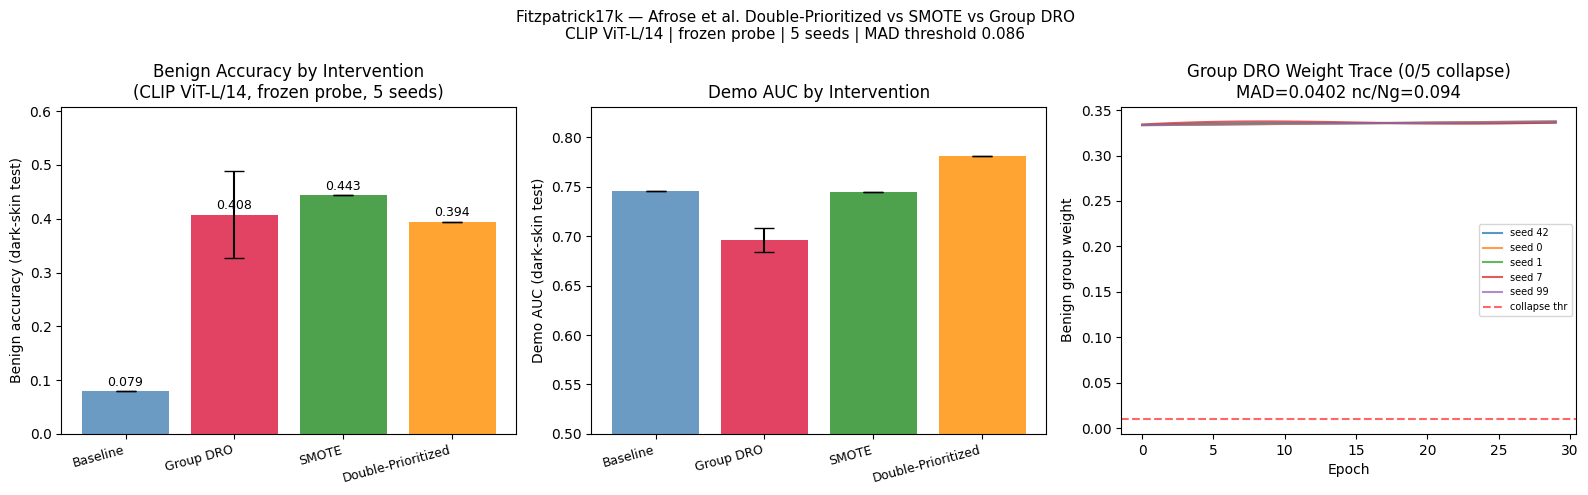

Figure saved: afrose_comparison_results.png

=== LaTeX TABLE ROWS ===
Baseline & 0.746±0.000 & 0.039±0.011 & 0.079±0.000 & [0.0476,0.1219] & — \\
Group DRO & 0.696±0.012 & 0.089±0.014 & 0.408±0.081 & [0.2406,0.6142] & 0/5 \\
SMOTE & 0.745±0.000 & 0.040±0.011 & 0.443±0.000 & [0.3762,0.5121] & — \\
Double-Prioritized & 0.781±0.000 & 0.004±0.011 & 0.394±0.000 & [0.3288,0.4624] & — \\

=== INTERPRETATION ===
Baseline        benign acc: 0.079
Group DRO       benign acc: 0.408  (0/5 collapse)
SMOTE           benign acc: 0.443  (main paper result)
Double-Prior.   benign acc: 0.394  (Afrose et al. analogue)

SMOTE outperforms Double-Prioritized (0.443 vs 0.394).
Recommendation: SMOTE remains the recommended intervention.
Report Double-Prioritized result in Table 4 and discuss mechanistic
reason (feature-space interpolation may not capture double-priority
structure without image-space augmentation). Update Section 5.4.

Files: afrose_comparison_results.csv, afrose_comparison_table.csv,
       a

In [7]:
# ── Open envelope: comparison table and figure ────────────────

with open('sealed_afrose.json') as fh: _s = json.load(fh)
mad_str = f"{_s['mad_risk']:.4f}" if _s['mad_risk'] is not None else 'MAD-I'

print('=== OPEN ENVELOPE ===')
print(f'Sealed prediction : {_s["prediction"]}')
n_dro_col = sum(r['collapse'] for r in all_results['Group DRO'])
print(f'DRO collapse      : {n_dro_col}/5')
print()

print('=== INTERVENTION COMPARISON TABLE ===')
rows = []
for name, seed_rs in all_results.items():
    acc_m  = np.mean([r['ben_acc'] for r in seed_rs])
    acc_s  = np.std( [r['ben_acc'] for r in seed_rs])
    auc_m  = np.nanmean([r['demo_auc'] for r in seed_rs])
    auc_s  = np.nanstd( [r['demo_auc'] for r in seed_rs])
    sgg_m  = np.nanmean([r['sgg'] for r in seed_rs])
    sgg_s  = np.nanstd( [r['sgg'] for r in seed_rs])
    ci_lo  = min(r['ci_lo'] for r in seed_rs)
    ci_hi  = max(r['ci_hi'] for r in seed_rs)
    n_col  = sum(r.get('collapse', False) for r in seed_rs)
    rows.append({
        'Intervention'  : name,
        'Demo AUC'      : f'{auc_m:.3f}±{auc_s:.3f}',
        'SGG'           : f'{sgg_m:.3f}±{sgg_s:.3f}',
        'Benign Acc'    : f'{acc_m:.3f}±{acc_s:.3f}',
        'CI [lo,hi]'    : f'[{ci_lo:.4f},{ci_hi:.4f}]',
        'DRO Collapse'  : f'{n_col}/5' if name == 'Group DRO' else '—',
        '_acc_m'        : acc_m, '_auc_m': auc_m, '_sgg_m': sgg_m,
    })

df_compare = pd.DataFrame(rows)
print(df_compare[['Intervention','Demo AUC','SGG','Benign Acc',
                   'CI [lo,hi]','DRO Collapse']].to_string(index=False))
df_compare.drop(columns=['_acc_m','_auc_m','_sgg_m']).to_csv(
    'afrose_comparison_table.csv', index=False)

# ── Figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Benign accuracy by intervention
ax = axes[0]
colors = {'Baseline':'steelblue','Group DRO':'crimson',
          'SMOTE':'forestgreen','Double-Prioritized':'darkorange'}
acc_vals = [(r['Intervention'], r['_acc_m'],
             np.std([x['ben_acc'] for x in all_results[r['Intervention']]]))
            for _, r in df_compare.iterrows()]
bars = ax.bar([v[0] for v in acc_vals], [v[1] for v in acc_vals],
              yerr=[v[2] for v in acc_vals],
              color=[colors[v[0]] for v in acc_vals],
              alpha=0.8, capsize=7)
ax.set_ylabel('Benign accuracy (dark-skin test)')
ax.set_title('Benign Accuracy by Intervention\n(CLIP ViT-L/14, frozen probe, 5 seeds)')
ax.set_xticklabels([v[0] for v in acc_vals], rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, [v[1] for v in acc_vals]):
    ax.text(bar.get_x()+bar.get_width()/2., val+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(v[1]+v[2] for v in acc_vals)+0.12)

# Panel 2: Demo AUC
ax = axes[1]
auc_vals = [(r['Intervention'], r['_auc_m'],
             np.nanstd([x['demo_auc'] for x in all_results[r['Intervention']]]))
            for _, r in df_compare.iterrows()]
ax.bar([v[0] for v in auc_vals], [v[1] for v in auc_vals],
       yerr=[v[2] for v in auc_vals],
       color=[colors[v[0]] for v in auc_vals], alpha=0.8, capsize=7)
ax.set_ylabel('Demo AUC (dark-skin test)')
ax.set_title('Demo AUC by Intervention')
ax.set_xticklabels([v[0] for v in auc_vals], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.5, min(1.0, max(v[1]+v[2] for v in auc_vals)+0.05))

# Panel 3: DRO weight trace
ax = axes[2]
for i, trace in enumerate(dro_wt_traces[:5]):
    ax.plot(trace, alpha=0.75, label=f'seed {SEEDS[i]}')
ax.axhline(COLLAPSE_THR, color='red', linestyle='--', alpha=0.6, label='collapse thr')
ax.set_xlabel('Epoch'); ax.set_ylabel('Benign group weight')
n_col_s = sum(r['collapse'] for r in all_results['Group DRO'])
ax.set_title(f'Group DRO Weight Trace ({n_col_s}/5 collapse)\n'
             f'MAD={mad_str} nc/Ng={nc_ng:.3f}')
ax.legend(fontsize=7)

plt.suptitle(
    f'Fitzpatrick17k — Afrose et al. Double-Prioritized vs SMOTE vs Group DRO\n'
    f'CLIP ViT-L/14 | frozen probe | 5 seeds | MAD threshold {MAD_THRESHOLD}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('afrose_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: afrose_comparison_results.png')

print('\n=== LaTeX TABLE ROWS ===')
for _, r in df_compare.iterrows():
    col_str = r['DRO Collapse'] if r['DRO Collapse'] != '—' else '—'
    print(f"{r['Intervention']} & {r['Demo AUC']} & {r['SGG']} & "
          f"{r['Benign Acc']} & {r['CI [lo,hi]']} & {col_str} \\\\")

print('\n=== INTERPRETATION ===')
bl_acc  = df_compare[df_compare['Intervention']=='Baseline']['_acc_m'].values[0]
sm_acc  = df_compare[df_compare['Intervention']=='SMOTE']['_acc_m'].values[0]
dp_acc  = df_compare[df_compare['Intervention']=='Double-Prioritized']['_acc_m'].values[0]
dro_acc = df_compare[df_compare['Intervention']=='Group DRO']['_acc_m'].values[0]

print(f'Baseline        benign acc: {bl_acc:.3f}')
print(f'Group DRO       benign acc: {dro_acc:.3f}  ({n_dro_col}/5 collapse)')
print(f'SMOTE           benign acc: {sm_acc:.3f}  (main paper result)')
print(f'Double-Prior.   benign acc: {dp_acc:.3f}  (Afrose et al. analogue)')
print()

if dp_acc > sm_acc:
    print(f'Double-Prioritized OUTPERFORMS SMOTE ({dp_acc:.3f} vs {sm_acc:.3f}).')
    print('Recommendation: Update Section 5.3. Double-Prioritized should be')
    print('the recommended intervention when nc/Ng is low and demographic')
    print('shift is present. Revise SMOTE-first recommendation accordingly.')
elif abs(dp_acc - sm_acc) < 0.03:
    print(f'Double-Prioritized is COMPARABLE to SMOTE ({dp_acc:.3f} vs {sm_acc:.3f}, diff<3pp).')
    print('Recommendation: Both methods recover benign accuracy. Report both in')
    print('Table 4. Note in Section 5.3 that Afrose method does not improve over')
    print('SMOTE on this benchmark, though it provides theoretical coverage of the')
    print('minority-within-minority structure. Update limitations (Section 5.4).')
else:
    print(f'SMOTE outperforms Double-Prioritized ({sm_acc:.3f} vs {dp_acc:.3f}).')
    print('Recommendation: SMOTE remains the recommended intervention.')
    print('Report Double-Prioritized result in Table 4 and discuss mechanistic')
    print('reason (feature-space interpolation may not capture double-priority')
    print('structure without image-space augmentation). Update Section 5.4.')

print(f'\nFiles: afrose_comparison_results.csv, afrose_comparison_table.csv,')
print(f'       afrose_comparison_results.png, sealed_afrose.json')
print('Paste ALL output to Claude for manuscript update.')
